#  Machine Learning Lifecycle



In [112]:
# ============================================================
# Step 1: Import required libraries
# ============================================================

# pandas is used to read and analyze tabular data
import pandas as pd

# numpy is useful for numerical operations
import numpy as np

# matplotlib is used for basic charts
import matplotlib.pyplot as plt

# train_test_split splits data into training and testing parts
from sklearn.model_selection import train_test_split

# RandomForestClassifier is the ML algorithm used in this example
from sklearn.ensemble import RandomForestClassifier

# Metrics are used to validate classification model performance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# pickle saves the trained model as a file
import pickle

print('Libraries imported successfully.')

Libraries imported successfully.


In [113]:
# ============================================================
# Step 2: Read the CSV file
# ============================================================

# This is a customer churn dataset.
# Churn means whether the customer left the service or not.
# Target column: churn
# churn = Yes means customer left
# churn = No means customer did not leave

df = pd.read_csv('../datasets/customer_churn_simple.csv')

# Display first 5 rows
df.head()

,customer_id,age,tenure_months,monthly_charges,support_tickets,usage_gb,late_payments,city,gender,contract_type,internet_service,payment_method,churn
0,CUST0001,54,45,1969.12,2,81.81,1,Chennai,Male,Two year,Fiber optic,Net Banking,No
1,CUST0002,47,34,2842.35,2,446.67,1,Mumbai,Male,Month-to-month,Fiber optic,Credit Card,No
2,CUST0003,61,9,3130.00,0,387.65,0,NaN,Female,One year,DSL,UPI,Yes
3,CUST0004,21,8,1403.30,0,192.87,2,Mumbai,Male,Two year,Fiber optic,Debit Card,No
4,CUST0005,28,7,1777.90,1,374.80,1,Mumbai,Female,Month-to-month,No,UPI,No


In [114]:
# ============================================================
# Step 3: Basic EDA - Understand the data
# ============================================================

# shape gives number of rows and columns
print('Rows and columns:', df.shape)

# columns gives all column names
print('Column names:')
print(df.columns.tolist())

# info gives data types and non-null counts
print('Dataset information:')
df.info()

Rows and columns: (600, 13)
Column names:
['customer_id', 'age', 'tenure_months', 'monthly_charges', 'support_tickets', 'usage_gb', 'late_payments', 'city', 'gender', 'contract_type', 'internet_service', 'payment_method', 'churn']
Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       600 non-null    object 
 1   age               600 non-null    int64  
 2   tenure_months     600 non-null    int64  
 3   monthly_charges   592 non-null    float64
 4   support_tickets   600 non-null    int64  
 5   usage_gb          600 non-null    float64
 6   late_payments     600 non-null    int64  
 7   city              592 non-null    object 
 8   gender            600 non-null    object 
 9   contract_type     600 non-null    object 
 10  internet_service  600 non-null    object 
 11  payment_method    592 non-n

In [115]:
# ============================================================
# Step 4: Statistical summary
# ============================================================

# describe gives statistical summary of numerical columns.
# It shows count, mean, standard deviation, minimum and maximum values.
df.describe()

,age,tenure_months,monthly_charges,support_tickets,usage_gb,late_payments
count,600.000000,600.00000,592.000000,600.000000,600.000000,600.000000
mean,45.865000,37.11500,1959.354274,1.900000,298.106500,1.035000
std,14.212322,20.57565,898.987517,1.389202,175.940077,1.004385
min,21.000000,1.00000,310.050000,0.000000,5.370000,0.000000
25%,33.000000,20.00000,1240.500000,1.000000,137.582500,0.000000
50%,46.000000,38.00000,1993.770000,2.000000,298.790000,1.000000
75%,58.000000,55.00000,2712.055000,3.000000,445.120000,2.000000
max,69.000000,71.00000,3488.470000,7.000000,599.000000,5.000000


In [116]:
# ============================================================
# Step 5: Check missing values
# ============================================================

# Missing values can create problems during model training.
# Here we check how many missing values are present in each column.
df.isnull().sum()

customer_id         0
age                 0
tenure_months       0
monthly_charges     8
support_tickets     0
usage_gb            0
late_payments       0
city                8
gender              0
contract_type       0
internet_service    0
payment_method      8
churn               0
dtype: int64

churn
No     450
Yes    150
Name: count, dtype: int64


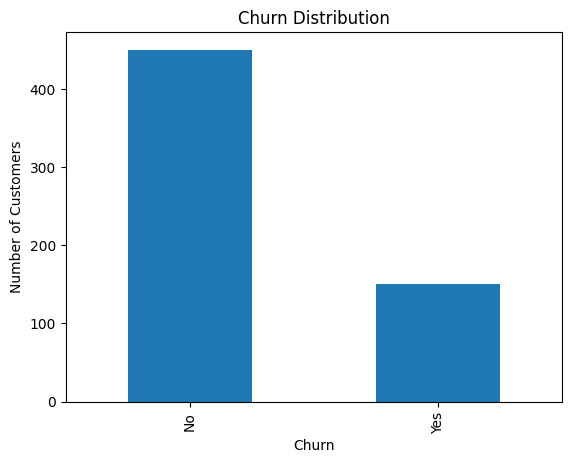

In [117]:
# ============================================================
# Step 6: Check target column distribution
# ============================================================

# This tells us how many customers churned and how many did not.
print(df['churn'].value_counts())

# Simple bar chart for target distribution
df['churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

In [118]:
# ============================================================
# Step 7: Categorical column analysis
# ============================================================

# This shows unique values and frequency for text/category columns.
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_columns:
    print('Column:', col)
    print(df[col].value_counts(dropna=False).head(10))

Column: customer_id
customer_id
CUST0001    1
CUST0395    1
CUST0397    1
CUST0398    1
CUST0399    1
CUST0400    1
CUST0401    1
CUST0402    1
CUST0403    1
CUST0404    1
Name: count, dtype: int64
Column: city
city
Chennai      134
Hyderabad    122
Mumbai       121
Bangalore    110
Pune         105
NaN            8
Name: count, dtype: int64
Column: gender
gender
Female    314
Male      286
Name: count, dtype: int64
Column: contract_type
contract_type
Month-to-month    335
One year          171
Two year           94
Name: count, dtype: int64
Column: internet_service
internet_service
Fiber optic    287
DSL            215
No              98
Name: count, dtype: int64
Column: payment_method
payment_method
Net Banking    157
UPI            152
Credit Card    146
Debit Card     137
NaN              8
Name: count, dtype: int64
Column: churn
churn
No     450
Yes    150
Name: count, dtype: int64


In [119]:
# ============================================================
# Step 8: Handle missing values in a simple way
# ============================================================

# For numerical columns, fill missing values with median.
# Median is the middle value and is safer than mean when outliers exist.

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# For categorical columns, fill missing values with mode.
# Mode means the most frequently occurring value.

categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check missing values again
print(df.isnull().sum())

customer_id         0
age                 0
tenure_months       0
monthly_charges     0
support_tickets     0
usage_gb            0
late_payments       0
city                0
gender              0
contract_type       0
internet_service    0
payment_method      0
churn               0
dtype: int64


In [120]:
# ============================================================
# Step 9: Prepare data for machine learning
# ============================================================

# Machine learning algorithms need numerical input.
# Our dataset has text/category columns such as city, gender and contract_type.
# To keep it simple, we use pandas get_dummies() for one-hot encoding.

# Drop customer_id because it is only an identifier.
# It does not help the model learn useful patterns.
df_model = df.drop('customer_id', axis=1)

# Convert target column churn into numbers.
# Yes = 1 means customer churned
# No = 0 means customer did not churn
df_model['churn'] = df_model['churn'].map({'Yes': 1, 'No': 0})

# Convert categorical columns into dummy/one-hot encoded columns.
# Example:
# city = Hyderabad, Pune, Chennai
# becomes city_Hyderabad, city_Pune, city_Chennai
# drop_first=True removes one category from each categorical column
# to avoid unnecessary duplicate information.
df_model = pd.get_dummies(df_model, drop_first=True)

# Show transformed data
df_model.head()

,age,tenure_months,monthly_charges,support_tickets,usage_gb,late_payments,churn,city_Chennai,city_Hyderabad,city_Mumbai,city_Pune,gender_Male,contract_type_One year,contract_type_Two year,internet_service_Fiber optic,internet_service_No,payment_method_Debit Card,payment_method_Net Banking,payment_method_UPI
0,54,45,1969.12,2,81.81,1,0,True,False,False,False,True,False,True,True,False,False,True,False
1,47,34,2842.35,2,446.67,1,0,False,False,True,False,True,False,False,True,False,False,False,False
2,61,9,3130.00,0,387.65,0,1,True,False,False,False,False,True,False,False,False,False,False,True
3,21,8,1403.30,0,192.87,2,0,False,False,True,False,True,False,True,True,False,True,False,False
4,28,7,1777.90,1,374.80,1,0,False,False,True,False,False,False,False,False,True,False,False,True


In [121]:
# ============================================================
# Step 10: Separate input features X and target y
# ============================================================

# X contains all input columns used for prediction.
X = df_model.drop('churn', axis=1)

# y contains the output/target column.
y = df_model['churn']

print('Input feature shape:', X.shape)
print('Target shape:', y.shape)

Input feature shape: (600, 18)
Target shape: (600,)


In [122]:
# ============================================================
# Step 11: Train-test split
# ============================================================

# We split the dataset into training and testing data.
# Training data is used to teach the model.
# Testing data is used to check how well the model performs on unseen data.
#
# test_size=0.2 means:
# 80% data for training
# 20% data for testing
#
# random_state=42 ensures same split every time we run the notebook.
# stratify=y keeps the same churn Yes/No ratio in train and test data.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (480, 18)
X_test shape: (120, 18)
y_train shape: (480,)
y_test shape: (120,)


In [123]:
# ============================================================
# Step 12: Choose algorithm and build model
# ============================================================

# We are using RandomForestClassifier.
#
# Why Random Forest?
# - It works well for classification problems
# - It can handle numerical and encoded categorical columns
# - Scaling is usually not mandatory
# - It combines many decision trees to make better predictions
#
# n_estimators=100 means the model will create 100 decision trees.
# random_state=42 gives reproducible results.

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model using training data
model.fit(X_train, y_train)

print('Model training completed successfully.')

Model training completed successfully.


In [124]:
# ============================================================
# Step 13: Predict using the trained model
# ============================================================

# Now the model will predict churn for X_test data.
# X_test is unseen data for the model.
y_pred = model.predict(X_test)

# Display first 10 predictions
print('First 10 predictions:')
print(y_pred[:10])

First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]


In [125]:
# ============================================================
# Step 14: Validate model using evaluation metrics
# ============================================================

# Accuracy:
# Accuracy tells how many total predictions are correct.
# Example:
# If model predicted 80 correct out of 100, accuracy = 80%.
# Good when classes are balanced.
accuracy = accuracy_score(y_test, y_pred)

# Precision:
# Precision answers:
# Out of all customers predicted as churn, how many really churned?
# Useful when false alarms are costly.
# Example:
# If model says 20 customers will churn, but only 15 actually churn,
# precision = 15/20.
precision = precision_score(y_test, y_pred)

# Recall:
# Recall answers:
# Out of all actual churn customers, how many did the model catch?
# Useful when missing churn customers is costly.
# Example:
# If 30 customers actually churned and model found 24,
# recall = 24/30.
recall = recall_score(y_test, y_pred)

# F1 Score:
# F1 score is the balance between precision and recall.
# It is useful when we want a single score that considers both
# false positives and false negatives.
f1 = f1_score(y_test, y_pred)

print('Accuracy :', round(accuracy, 4))
print('Precision:', round(precision, 4))
print('Recall   :', round(recall, 4))
print('F1 Score :', round(f1, 4))

Accuracy : 0.7417
Precision: 0.3333
Recall   : 0.0333
F1 Score : 0.0606


In [126]:
# ============================================================
# Step 15: Confusion Matrix
# ============================================================

# Confusion matrix shows correct and wrong predictions in detail.
#
# For binary classification:
#
# TN = True Negative
# Customer did not churn and model predicted not churn.
#
# FP = False Positive
# Customer did not churn but model predicted churn.
# This is a false alarm.
#
# FN = False Negative
# Customer churned but model predicted not churn.
# This is risky in churn prediction because we miss a customer who may leave.
#
# TP = True Positive
# Customer churned and model predicted churn.

cm = confusion_matrix(y_test, y_pred)

print('Confusion Matrix:')
print(cm)

tn, fp, fn, tp = cm.ravel()

print('True Negative :', tn)
print('False Positive:', fp)
print('False Negative:', fn)
print('True Positive :', tp)

Confusion Matrix:
[[88  2]
 [29  1]]
True Negative : 88
False Positive: 2
False Negative: 29
True Positive : 1


In [127]:
# ============================================================
# Step 16: Classification Report
# ============================================================

# classification_report gives precision, recall and f1-score
# separately for each class.
#
# Class 0 = No Churn
# Class 1 = Churn

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.98      0.85        90
           1       0.33      0.03      0.06        30

    accuracy                           0.74       120
   macro avg       0.54      0.51      0.46       120
weighted avg       0.65      0.74      0.65       120



In [128]:
# ============================================================
# Step 17: Compare actual and predicted values
# ============================================================

# This table helps us see actual output and predicted output side by side.
result_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

result_df.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,1,0
4,0,0
5,1,0
6,0,0
7,1,0
8,1,0
9,0,0


In [129]:
# ============================================================
# Step 18: Feature importance
# ============================================================

# Random Forest can tell which features were more important.
# Higher importance means the column contributed more to prediction.

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
1,tenure_months,0.165421
2,monthly_charges,0.158546
4,usage_gb,0.134673
0,age,0.128832
3,support_tickets,0.073650
5,late_payments,0.066897
11,contract_type_One year,0.030278
10,gender_Male,0.027676
16,payment_method_Net Banking,0.025547
12,contract_type_Two year,0.024418


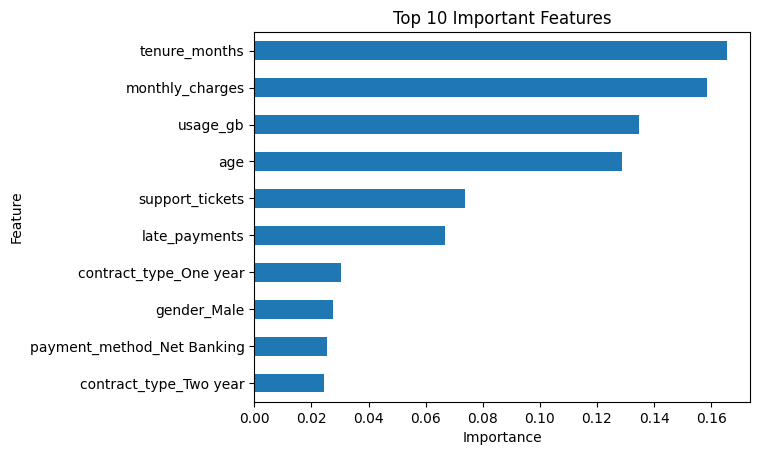

In [130]:
# Plot top 10 important features
feature_importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    legend=False
)

plt.title('Top 10 Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()

In [131]:
# ============================================================
# Step 19: Save the trained model as a pickle file
# ============================================================

# Pickle is used to save Python objects into a file.
# Here we save the trained Random Forest model.
#
# Later, we can load this pickle file and use it for prediction
# without training the model again.

model_file_path = '../models/random_forest_churn_model.pkl'

with open(model_file_path, 'wb') as file:
    pickle.dump(model, file)

print('Model saved successfully at:', model_file_path)

Model saved successfully at: ../models/random_forest_churn_model.pkl


In [132]:
# ============================================================
# Step 20: Load the pickle file and test prediction again
# ============================================================

# This step confirms that our saved model is working correctly.

with open('../models/random_forest_churn_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Predict again using loaded model
loaded_predictions = loaded_model.predict(X_test)

print('First 10 predictions from loaded model:')
print(loaded_predictions[:10])

print('Loaded model accuracy:', accuracy_score(y_test, loaded_predictions))

First 10 predictions from loaded model:
[0 0 0 0 0 0 0 0 0 0]
Loaded model accuracy: 0.7416666666666667
